In [1]:
import os, sys, traceback
import importlib.machinery
import geopandas as gpd

In [74]:
# specify input variable file
in_GlobalVar_txt     = "py_Variables - vt_JsonVars.txt"

# get path to script launch point (i.e. location of 'HailMary.s' or '*.ipynb')
dir_ScriptLaunch = os.getcwd()

path_in_GlobalVar_txt = os.path.join(dir_ScriptLaunch, in_GlobalVar_txt)

# create variables from input file global variables
GlobalVars = importlib.machinery.SourceFileLoader('data', path_in_GlobalVar_txt).load_module()

ParentDir         = GlobalVars.ParentDir
ScenarioDir       = GlobalVars.ScenarioDir
ModelVersion      = GlobalVars.ModelVersion
TAZ_SHP_Name      = GlobalVars.TAZ_DBF.replace(".dbf", ".shp")
Segments_SHP_Name = GlobalVars.Segments_DBF.replace(".dbf", ".shp")
TAZ_Geo_Name      = TAZ_SHP_Name.replace(".shp", "")
Segments_Geo_Name = Segments_SHP_Name.replace(".shp", "")

In [75]:
TAZ_SHP        = os.path.join(ParentDir, r"1_Inputs\1_TAZ", TAZ_SHP_Name)
Segments_SHP   = os.path.join(ParentDir, r"1_Inputs\6_Segment", Segments_SHP_Name)

output_path = os.path.join(ParentDir, r"Scenarios\.vizTool\geo-data")
print(output_path)

D:\GitHub\WF-TDM-v9x\\Scenarios\.vizTool\geo-data


In [82]:
def read_in_shp(shp_path, tolerance=0.0001):
    # read in shapefile and transform to projection
    gdf = gpd.read_file(shp_path)
    gdf = gdf.to_crs(epsg=4326)

    # simplify geometry
    gdf['geometry'] = gdf['geometry'].simplify(tolerance, preserve_topology=True)

    return gdf

In [77]:
def dissolve_taz(gdf, field1, field2=None):
    if field2:
        # Dissolve based on two fields
        gdf = gdf[[field1,field2,'geometry']]
        dissolved = gdf.dissolve(by=[field1, field2]).reset_index()
        
    else:
        # Dissolve based on one field
        gdf = gdf[[field1,'geometry']]
        dissolved = gdf.dissolve(by=field1).reset_index()

    return dissolved


In [78]:
def convert_shp_to_geojson(gdf, geojson_path):
    # plot geodataframe
    gdf.plot()

    # Convert to GeoJSON and save it to the specified path
    gdf.to_file(geojson_path, driver='GeoJSON')


In [79]:
taz_gdf  = read_in_shp(TAZ_SHP)
seg_gdf  = read_in_shp(Segments_SHP)

dsml_gdf = dissolve_taz(taz_gdf, "DISTSML"  , "DSML_NAME")
dmed_gdf = dissolve_taz(taz_gdf, "DISTMED"  , "DMED_NAME")
dlrg_gdf = dissolve_taz(taz_gdf, "DISTLRG"  , "DLRG_NAME")
dsup_gdf = dissolve_taz(taz_gdf, "DISTSUPER", "DSUP_NAME")
city_gdf = dissolve_taz(taz_gdf, "CITY_NAME"             )
said_gdf = dissolve_taz(taz_gdf, "SUBAREAID"             )

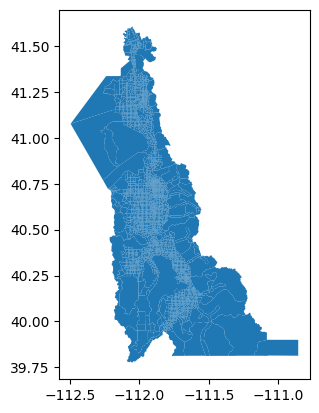

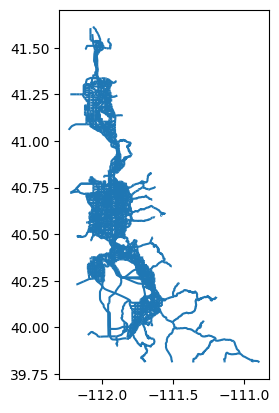

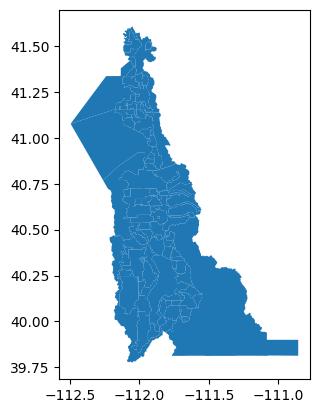

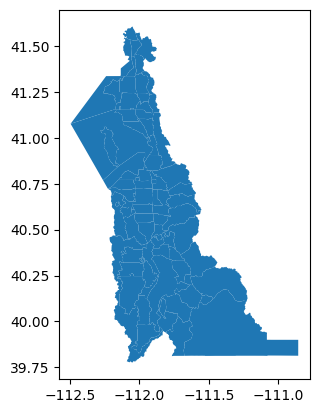

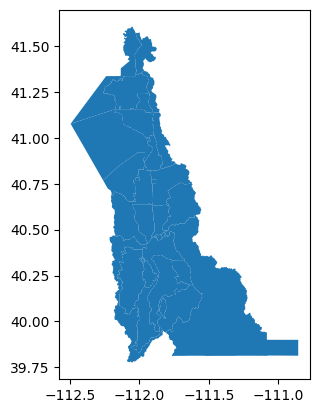

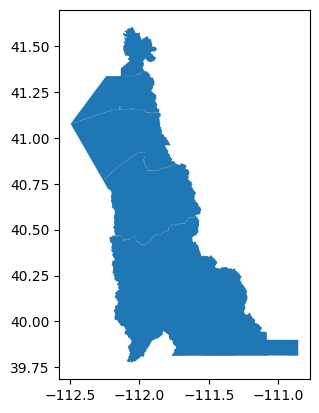

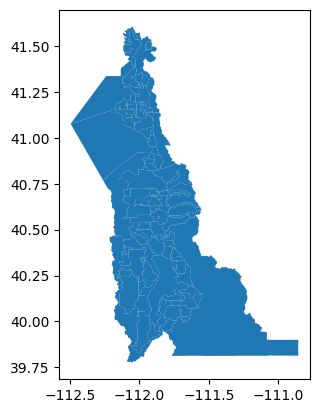

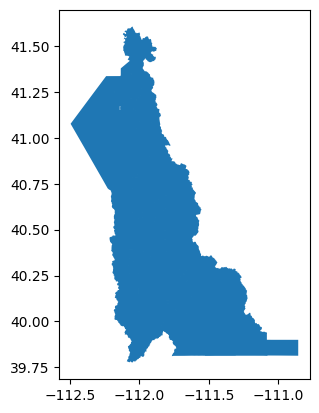

In [81]:
# Perform the conversion
convert_shp_to_geojson(taz_gdf , os.path.join(output_path, TAZ_Geo_Name                + ".geojson"))
convert_shp_to_geojson(seg_gdf , os.path.join(output_path, Segments_Geo_Name           + ".geojson"))
convert_shp_to_geojson(dsml_gdf, os.path.join(output_path, TAZ_Geo_Name      + "_DSML" + ".geojson"))
convert_shp_to_geojson(dmed_gdf, os.path.join(output_path, TAZ_Geo_Name      + "_DMED" + ".geojson"))
convert_shp_to_geojson(dlrg_gdf, os.path.join(output_path, TAZ_Geo_Name      + "_DLRG" + ".geojson"))
convert_shp_to_geojson(dsup_gdf, os.path.join(output_path, TAZ_Geo_Name      + "_DSUP" + ".geojson"))
convert_shp_to_geojson(city_gdf, os.path.join(output_path, TAZ_Geo_Name      + "_CITY" + ".geojson"))
convert_shp_to_geojson(said_gdf, os.path.join(output_path, TAZ_Geo_Name      + "_SAID" + ".geojson"))